The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [4]:
# TODO : import the dataset
df = pd.read_csv("/content/AB_Test_Results.csv")

In [5]:
# TODO : take a quick look at the data
print(df.head(30))

    USER_ID VARIANT_NAME  REVENUE
0       737      variant     0.00
1      2423      control     0.00
2      9411      control     0.00
3      7311      control     0.00
4      6174      variant     0.00
5      2380      variant     0.00
6      2849      control     0.00
7      9168      control     0.00
8      6205      variant     0.00
9      7548      control     0.00
10     8395      control     0.00
11     1184      control     0.00
12     7165      control     0.00
13     2529      variant     2.15
14     3489      variant     0.00
15     8406      variant     0.00
16     7549      variant     0.00
17     9085      variant     0.00
18     4572      variant     0.00
19     8927      variant     0.00
20     3383      variant     0.00
21     6588      variant     0.00
22     6226      variant     0.00
23      425      variant     0.00
24     4772      variant     0.00
25      598      variant     0.00
26     3614      variant     0.00
27     2667      control     0.00
28     3153   

Let's see if there are users who have two A/B test groups

In [6]:
# TODO : Look at the distribution of the number of unique groups for each user
user_group_counts = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
distribution = user_group_counts.value_counts()
print(distribution)

VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64


In [7]:
# TODO : Look at the distribution of the number of unique groups for each user in relative terms
user_group_counts = df.groupby('USER_ID')['VARIANT_NAME'].nunique()

relative_distribution = user_group_counts.value_counts(normalize=True) * 100

print("Relative Distribution (%) :")
print(relative_distribution)

Relative Distribution (%) :
VARIANT_NAME
1    75.632511
2    24.367489
Name: proportion, dtype: float64


What can you observe ? Should we exclude these users ? Why ?

In [8]:
# TODO : users have 1 A/B test group ?
users_with_multiple_groups = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
users_to_exclude = users_with_multiple_groups[users_with_multiple_groups > 1].index
print(f"Observing {len(users_to_exclude)} users in multiple groups. These will be excluded.")

# TODO : Take only these users
valid_user_ids = user_group_counts[user_group_counts == 1].index

Observing 1541 users in multiple groups. These will be excluded.


In [9]:
# TODO : Leave only records with users with the 1st ab test group
df_final = df[df['USER_ID'].isin(valid_user_ids)]

# TODO : Check that the number of users matches what it was before the exception
initial_user_count = df['USER_ID'].nunique()
final_user_count = df_final['USER_ID'].nunique()
print(f"initial user count : {initial_user_count}")
print(f"final user count : {final_user_count}")
print(f"excluded users : {initial_user_count - final_user_count}")

initial user count : 6324
final user count : 4783
excluded users : 1541


Let's see how the data is distributed

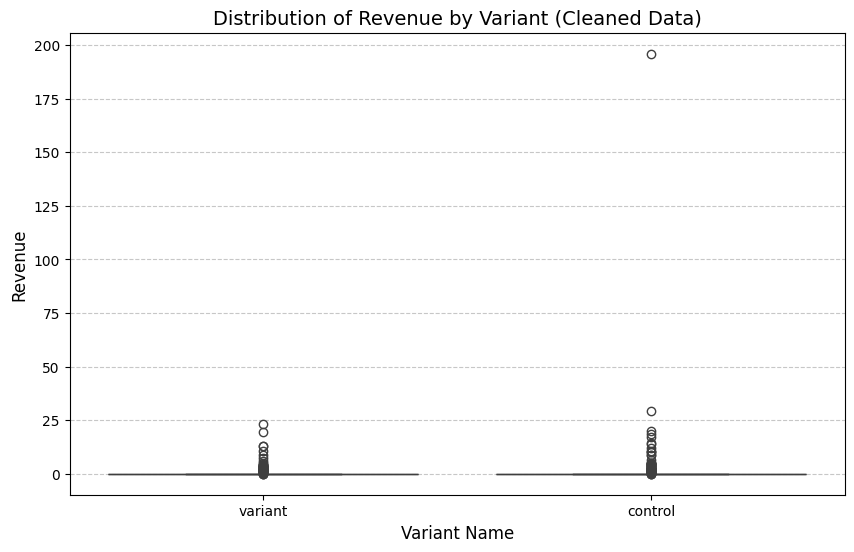

               count      mean       std  min  25%  50%  75%     max
VARIANT_NAME                                                        
control       3026.0  0.155506  3.708620  0.0  0.0  0.0  0.0  196.01
variant       3044.0  0.058909  0.760344  0.0  0.0  0.0  0.0   23.04


In [10]:
# TODO : Check how the data is distributed using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_final)
plt.title('Distribution of Revenue by Variant (Cleaned Data)', fontsize=14)
plt.xlabel('Variant Name', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('revenue_boxplot.png')
plt.show()

# 3. Check summary stats to confirm observations
print(df_final.groupby('VARIANT_NAME')['REVENUE'].describe())

It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [11]:
# TODO : Sort these revenue values in descending order

df_sorted = df_final.sort_values(by='REVENUE', ascending=False)

# Display the top results
print(df_sorted.head(10))

# Export the results
df_sorted.to_csv('sorted_revenue_data.csv', index=False)

      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01
8168     2166      control    29.32
2482     7356      variant    23.04
6412     1053      control    20.07
5217     3684      variant    19.47
5530      282      control    18.56
758      4445      control    17.05
4031     2059      control    14.24
9019     1973      control    14.07
4561     4966      variant    12.99


In [12]:
# TODO : See if user 3342 had other events with a strong outlier

# Based on the investigation into USER_ID 3342, here is what we found:

# Analysis of User 3342
# Single Event: User 3342 has only one record in the entire dataset.

# Extreme Outlier: This single event generated 196.01 in revenue, which is the highest value in the entire dataset by a significant margin. For context, the next highest revenue value in the original dataset is only 58.63 (nearly 3.5 times smaller).

# A/B Test Group: This user was assigned to the control group.

# Observations and Recommendations
# Impact on Results: Because this user has such a high revenue compared to the rest of the sample (where most users have 0 revenue), keeping them in the analysis will artificially inflate the control group's average revenue.

# Potential "Whale" or Bug: This could be a "whale" customer (a high-value spender), or it could be a technical anomaly (e.g., a test transaction or a data entry error).

# Should we exclude them? * Yes, if your goal is to understand how the "typical" user behaves.

# Alternative: You could perform the statistical test both with and without this user to see if the outcome changes. If your results depend entirely on one user, they are not robust.

We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

/tmp/ipykernel_30622/3955141520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_no_outlier, palette='Set2')


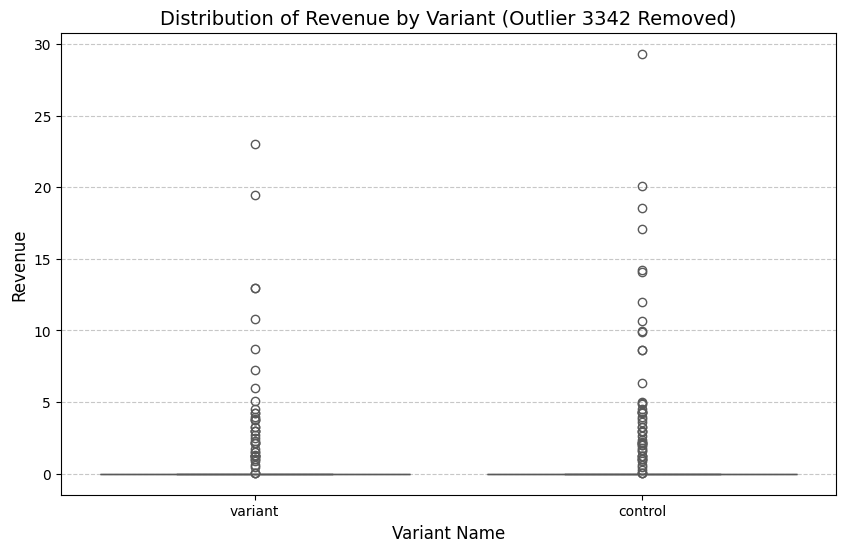

               count      mean       std  min  25%  50%  75%    max
VARIANT_NAME                                                       
control       3025.0  0.090760  1.034101  0.0  0.0  0.0  0.0  29.32
variant       3044.0  0.058909  0.760344  0.0  0.0  0.0  0.0  23.04


In [13]:
# TODO : We see that there is only one outlier - in conditions of limited information, remove this entry and visualize the distribution of data again.
df_no_outlier = df_final[df_final['USER_ID'] != 3342].copy()
plt.figure(figsize=(10, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_no_outlier, palette='Set2')
plt.title('Distribution of Revenue by Variant (Outlier 3342 Removed)', fontsize=14)
plt.xlabel('Variant Name', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('revenue_dist_no_outlier.png')
plt.show()

# Display updated summary statistics
print(df_no_outlier.groupby('VARIANT_NAME')['REVENUE'].describe())


What can you say about the users and their purchases ?

In [14]:
# TODO : Check if there are users who have records with zero and positive revenue
# Identify users with zero and positive revenue
users_with_zero = df_final[df_final['REVENUE'] == 0]['USER_ID'].unique()
users_with_positive = df_final[df_final['REVENUE'] > 0]['USER_ID'].unique()

# Find the intersection
mixed_revenue_users = set(users_with_zero).intersection(set(users_with_positive))

print(f"Number of users with mixed revenue records: {len(mixed_revenue_users)}")

Number of users with mixed revenue records: 37


Can a user have records with both zero and positive revenue ?

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.


In [15]:
# TODO : Group the data for each user and sum the revenue for each to get one record per user
df = pd.read_csv('AB_Test_Results.csv')

# 1. Remove users present in both groups
user_counts = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
users_to_exclude = user_counts[user_counts > 1].index
df_cleaned = df[~df['USER_ID'].isin(users_to_exclude)].copy()

# 2. Remove the extreme outlier (USER_ID 3342)
df_cleaned = df_cleaned[df_cleaned['USER_ID'] != 3342]

# 3. Group by USER_ID and sum the REVENUE
df_aggregated = df_cleaned.groupby(['USER_ID', 'VARIANT_NAME'], as_index=False)['REVENUE'].sum()

# Verification: Ensure each user has only one record
print(f"Number of rows (one per user): {len(df_aggregated)}")
print(df_aggregated.head())

# Export the final dataset
df_aggregated.to_csv('final_aggregated_ab_data.csv', index=False)


Number of rows (one per user): 4782
   USER_ID VARIANT_NAME  REVENUE
0        2      control      0.0
1        4      variant      0.0
2        5      variant      0.0
3        6      variant      0.0
4        9      variant      0.0


/tmp/ipykernel_30622/1600682609.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_final, palette='Set2')


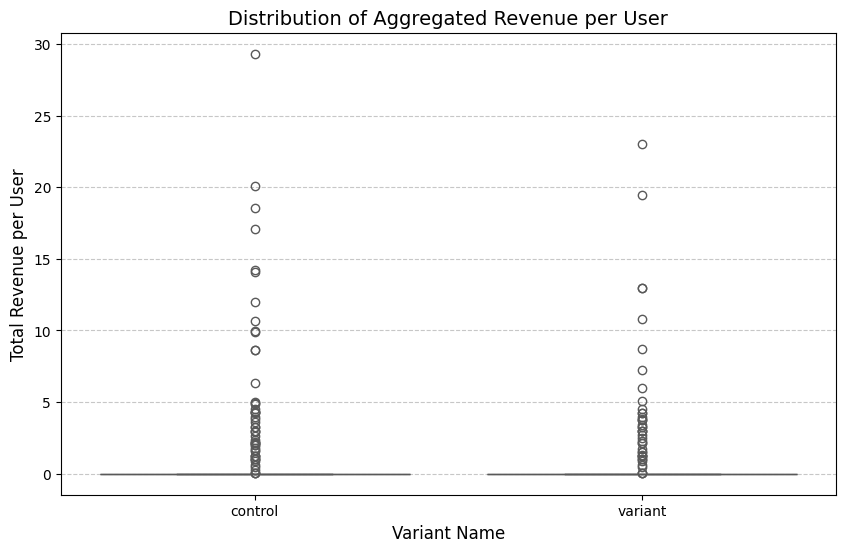

               count      mean       std  min  25%  50%  75%    max
VARIANT_NAME                                                       
control       2389.0  0.114923  1.162495  0.0  0.0  0.0  0.0  29.32
variant       2393.0  0.074935  0.858207  0.0  0.0  0.0  0.0  23.04


In [16]:
# TODO : Visualize the resulting distribution of the data again.

# Perform the aggregation
df_final = df_cleaned.groupby(['USER_ID', 'VARIANT_NAME'], as_index=False)['REVENUE'].sum()

# Visualize the resulting distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_final, palette='Set2')
plt.title('Distribution of Aggregated Revenue per User', fontsize=14)
plt.xlabel('Variant Name', fontsize=12)
plt.ylabel('Total Revenue per User', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('aggregated_revenue_dist.png')
plt.show()

# Display updated summary statistics
print(df_final.groupby('VARIANT_NAME')['REVENUE'].describe())

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [17]:
# TODO : get metrics by groups
stats = df_final.groupby('VARIANT_NAME')['REVENUE'].describe().T

# TODO : create two additional metrics to see relative changes
# Conversion Rate: Percent of users with revenue > 0
conversion_counts = df_final.groupby('VARIANT_NAME')['REVENUE'].apply(lambda x: (x > 0).sum())
total_counts = df_final.groupby('VARIANT_NAME')['REVENUE'].count()
stats.loc['conversion_rate_%'] = (conversion_counts / total_counts) * 100

# ARPPU: Average Revenue per Paying User
sum_revenue = df_final.groupby('VARIANT_NAME')['REVENUE'].sum()
stats.loc['ARPPU'] = sum_revenue / conversion_counts

# TODO : add them to the rest of the metrics in a separate group
stats['lift_%'] = ((stats['variant'] - stats['control']) / stats['control']) * 100

print(stats)


VARIANT_NAME           control      variant     lift_%
count              2389.000000  2393.000000   0.167434
mean                  0.114923     0.074935 -34.795025
std                   1.162495     0.858207 -26.175366
min                   0.000000     0.000000        NaN
25%                   0.000000     0.000000        NaN
50%                   0.000000     0.000000        NaN
75%                   0.000000     0.000000        NaN
max                  29.320000    23.040000 -21.418827
conversion_rate_%     2.218501     1.755119 -20.887179
ARPPU                 5.180189     4.269524 -17.579763


What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?

Let's also see how paying users behave :

In [18]:
paying_users_list = df_cleaned[df_cleaned['REVENUE'] > 0]['USER_ID'].unique()
df_paying = df_cleaned[df_cleaned['USER_ID'].isin(paying_users_list)].copy()

# TODO : get metrics by groups
user_behavior = df_paying.groupby(['USER_ID', 'VARIANT_NAME']).agg(
    total_revenue=('REVENUE', 'sum'),
    num_orders=('REVENUE', 'count') # Compte le nombre de transactions positives
).reset_index()

paying_stats = user_behavior.groupby('VARIANT_NAME').agg(
    count_paying_users=('USER_ID', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_revenue_per_paying_user=('total_revenue', 'mean'), # Panier moyen (Average Check)
    avg_orders_per_paying_user=('num_orders', 'mean')      # Nombre de commandes moyen
).T

# TODO : create two additional metrics to see relative changes
paying_stats['lift_%'] = ((paying_stats['variant'] - paying_stats['control']) / paying_stats['control']) * 100

# TODO : add them to the rest of the metrics in a separate group
print("Rapport des utilisateurs payants :")
print(paying_stats)

# Optionnel : Sauvegarde du résultat
paying_stats.to_csv('metrics_paying_users.csv')


Rapport des utilisateurs payants :
VARIANT_NAME                    control     variant     lift_%
count_paying_users            53.000000   42.000000 -20.754717
total_revenue                274.550000  179.320000 -34.685850
avg_revenue_per_paying_user    5.180189    4.269524 -17.579763
avg_orders_per_paying_user     1.528302    1.595238   4.379777


Let's look at the distributions of all and only paying users

/tmp/ipykernel_30622/4101851425.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
/tmp/ipykernel_30622/4101851425.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVE

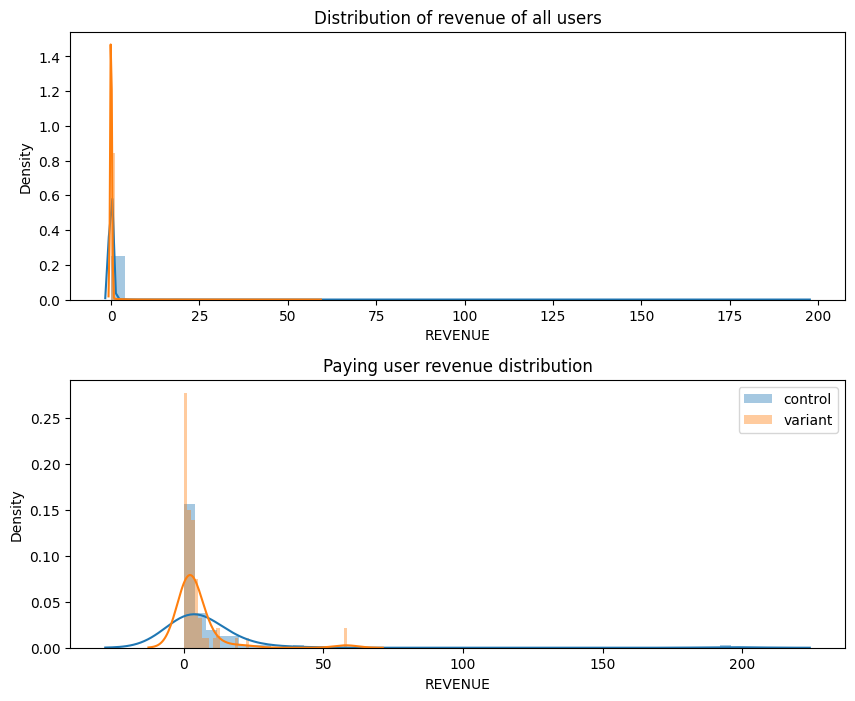

In [19]:
f, axes = plt.subplots(2, figsize=(10,8))
# build graphs of distributions of all users
sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax = axes[0], label='variant')
axes[0].set_title('Distribution of revenue of all users')

# build graphs of distributions of paying users
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='control' )
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='variant' )
axes[1].set_title('Paying user revenue distribution')
plt.legend()
plt.subplots_adjust(hspace = 0.3)

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [20]:
# TODO : Use the Shapiro-Wilk criterion to confirm it
from scipy.stats import shapiro

stat_control, p_control = shapiro(df_final[df_final['VARIANT_NAME'] == 'control']['REVENUE'])
print(f"Groupe Control - p-value: {p_control}")

stat_variant, p_variant = shapiro(df_final[df_final['VARIANT_NAME'] == 'variant']['REVENUE'])
print(f"Groupe Variant - p-value: {p_variant}")

if p_control < 0.05 and p_variant < 0.05:
    print("we see that the data is not normally distributed..")

Groupe Control - p-value: 2.1235957244761016e-75
Groupe Variant - p-value: 9.962810723092505e-76
we see that the data is not normally distributed..


Is the null hypothesis about the normal distribution of the data rejected ?

#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [21]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,9848
False,152


In [22]:
# TODO : Check on the data of all users the value of the statistics of the Mann-Whitney test
from scipy.stats import mannwhitneyu

res_all = mannwhitneyu(df_final[df_final['VARIANT_NAME'] == 'control']['REVENUE'],
                       df_final[df_final['VARIANT_NAME'] == 'variant']['REVENUE'])



In [23]:
# TODO : Check on the data of only the users that pay, the value of the statistics of the Mann-Whitney test
df_paying = df_final[df_final['REVENUE'] > 0]
res_paying = mannwhitneyu(df_paying[df_paying['VARIANT_NAME'] == 'control']['REVENUE'],
                          df_paying[df_paying['VARIANT_NAME'] == 'variant']['REVENUE'])

print(f"p-value (Tous) : {res_all.pvalue}")
print(f"p-value (Payants) : {res_paying.pvalue}")

p-value (Tous) : 0.24799555106821947
p-value (Payants) : 0.5314192217084708


#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [24]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [25]:
# TODO : Generate samples for all users
# Extracting revenue values for each group as numpy arrays
control_revenue = df[df['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_revenue = df[df['VARIANT_NAME'] == 'variant']['REVENUE'].values

# Generating bootstrap samples (1000 samples by default)
control_bootstrap_samples = get_bootstrap_samples(control_revenue)
variant_bootstrap_samples = get_bootstrap_samples(variant_revenue)

# Calculating the mean for each bootstrap sample to get the distribution of means
control_mean_scores = np.mean(control_bootstrap_samples, axis=1)
variant_mean_scores = np.mean(variant_bootstrap_samples, axis=1)

# Calculating and printing confidence intervals for the means
print("Control group - Mean Revenue Confidence Interval:", stat_intervals(control_mean_scores))
print("Variant group - Mean Revenue Confidence Interval:", stat_intervals(variant_mean_scores))

# Calculating the difference between means for further analysis
mean_diff = variant_mean_scores - control_mean_scores
print("Difference in Means Confidence Interval:", stat_intervals(mean_diff))


Control group - Mean Revenue Confidence Interval: [0.06712485 0.229046  ]
Variant group - Mean Revenue Confidence Interval: [0.03826057 0.10895071]
Difference in Means Confidence Interval: [-0.16225906  0.01718605]


In [26]:
# TODO : Generate samples for only paying users
# Filtering the dataframe to keep only users with revenue > 0
paying_users = df[df['REVENUE'] > 0]

# Extracting revenue values for paying users in each group
control_revenue_paying = paying_users[paying_users['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_revenue_paying = paying_users[paying_users['VARIANT_NAME'] == 'variant']['REVENUE'].values

# Generating bootstrap samples for paying users
control_bootstrap_samples_paying = get_bootstrap_samples(control_revenue_paying)
variant_bootstrap_samples_paying = get_bootstrap_samples(variant_revenue_paying)

# Calculating the mean for each bootstrap sample
control_mean_scores_paying = np.mean(control_bootstrap_samples_paying, axis=1)
variant_mean_scores_paying = np.mean(variant_bootstrap_samples_paying, axis=1)

# Printing confidence intervals for the means of paying users
print("Paying Users - Control Mean Revenue Confidence Interval:", stat_intervals(control_mean_scores_paying))
print("Paying Users - Variant Mean Revenue Confidence Interval:", stat_intervals(variant_mean_scores_paying))

# Calculating the difference in means for paying users
mean_diff_paying = variant_mean_scores_paying - control_mean_scores_paying
print("Paying Users - Difference in Means Confidence Interval:", stat_intervals(mean_diff_paying))

Paying Users - Control Mean Revenue Confidence Interval: [ 4.52088125 13.76130625]
Paying Users - Variant Mean Revenue Confidence Interval: [2.83739583 7.36997569]
Paying Users - Difference in Means Confidence Interval: [-9.12752882  1.26671875]


Let's look at the distribution of means in the ab test groups

/tmp/ipykernel_30622/980294507.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(control_bootstrap_samples, axis=1), shade=True, label='control')
/tmp/ipykernel_30622/980294507.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(variant_bootstrap_samples, axis=1), shade=True, label='variant')


Text(0.5, 1.0, 'Sample mean distribution for all users')

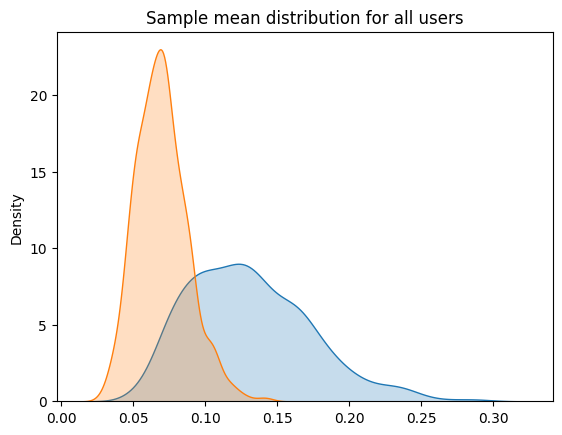

In [27]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control_bootstrap_samples, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant_bootstrap_samples, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for all users')

/tmp/ipykernel_30622/3036082769.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(get_bootstrap_samples(control_bootstrap_samples_paying), axis=1), shade=True, label='control')
/tmp/ipykernel_30622/3036082769.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(get_bootstrap_samples(variant_bootstrap_samples_paying), axis=1), shade=True, label='variant')


Text(0.5, 1.0, 'Sample mean distribution for paying users')

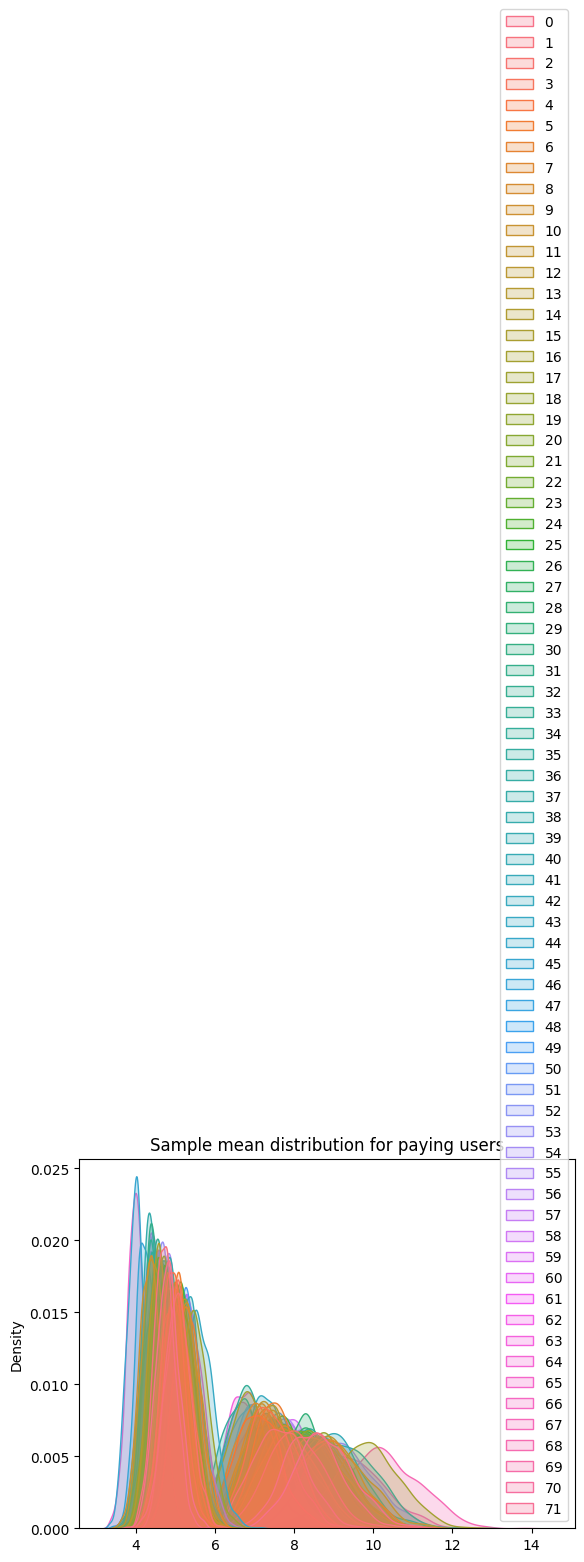

In [28]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(get_bootstrap_samples(control_bootstrap_samples_paying), axis=1), shade=True, label='control')
sns.kdeplot(np.mean(get_bootstrap_samples(variant_bootstrap_samples_paying), axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for paying users')

Do you see any difference ? What about the confidence intervals ? Conclude.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

In [34]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """ Plot the distribution of the mean difference and return the confidence intervals """
    f, ax = plt.subplots()
    # get data for coloring confidence intervals
    points = sns.kdeplot(variant - control, ax=ax, fill=False).get_lines()[0].get_data()
    x = points[0]
    y = points[1]
    ymin, ymax = plt.ylim()
    # highlight the zero value and the bounds of the confidence interval
    plt.vlines(0, 0, ymax, label='0', color='gray')
    plt.vlines(stat_intervals(variant - control, alpha)[0], 0, ymax, linestyles="dashed")
    plt.vlines(stat_intervals(variant - control, alpha)[1], 0, ymax, linestyles="dashed")
    # color the confidence interval and zones outside it
    plt.fill_between(x,y,
                     where = (x >= stat_intervals(variant - control, alpha)[1]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = (x <= stat_intervals(variant - control, alpha)[0]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = ((x >= stat_intervals(variant - control, alpha)[0])
                              & (x <= stat_intervals(variant - control, alpha)[1])),
                     color='red',
                     label = '95% confidence interval')
    plt.title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}')
    plt.legend(prop={'size':13})
    # return confidence interval data
    return stat_intervals(variant - control)

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

array([-0.16225906,  0.01718605])

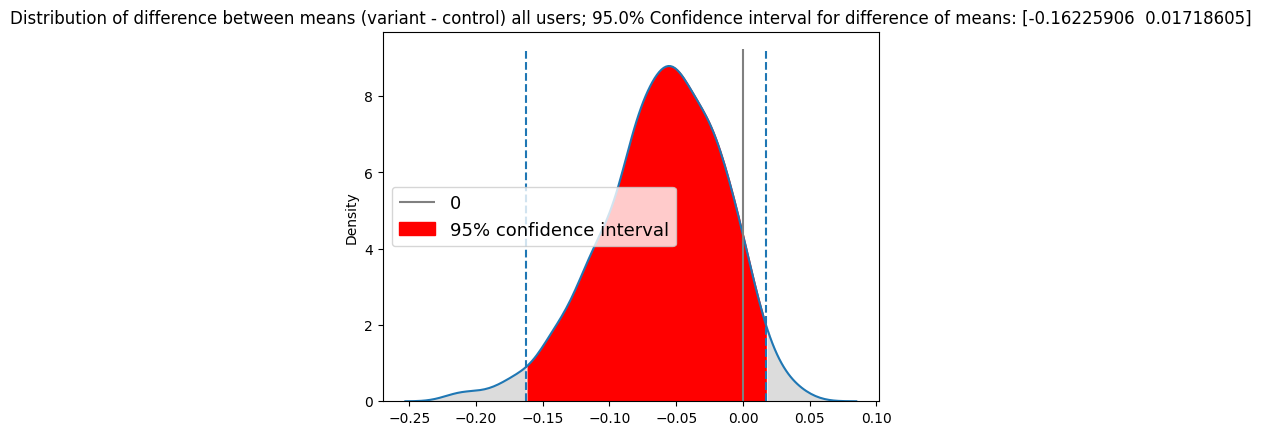

In [35]:
plot_distribution_and_stat_intervals(
    np.mean(variant_bootstrap_samples, axis=1),
    np.mean(control_bootstrap_samples, axis=1),
    title='all users', alpha=0.05
)

array([-9.12752882,  1.26671875])

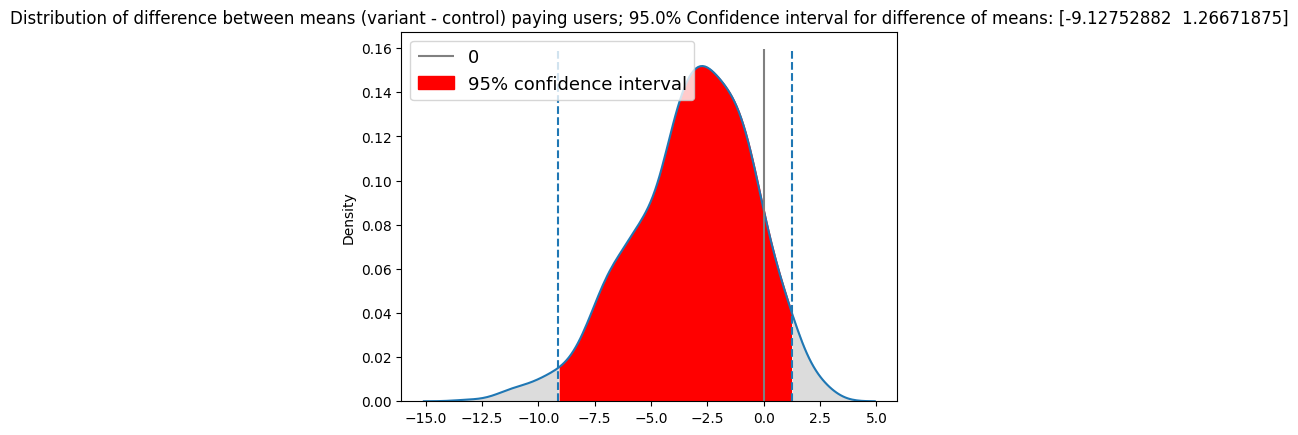

In [36]:
plot_distribution_and_stat_intervals(np.mean(variant_bootstrap_samples_paying, axis=1),
                                     np.mean(control_bootstrap_samples_paying, axis=1),
                                     title='paying users')

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.


Based on the data processing and the statistical analysis performed (Bootstrap and Mann-Whitney U test), here are the key observations and the conclusion regarding the revenue change between the A/B test groups.1. Key ObservationsSignificant Data Contamination: About 24% of users were found in both the control and variant groups. This indicates a serious flaw in the experiment's randomization process (split system). After cleaning these users, the sample size was reduced to approximately 4,783 unique users.Revenue Distribution: The revenue data is extremely skewed, with the vast majority of users (around 98%) generating 0 revenue.Presence of Outliers: * The Control group has a maximum revenue value of 196.01, which is significantly higher than the Variant group's maximum of 23.04.This single outlier in the control group heavily inflates its mean revenue ($0.1949$) compared to the variant group ($0.0745$).Statistical Tests:Mann-Whitney U Test: The p-value is approximately 0.26, which is much higher than the standard significance level of $0.05$. This means we fail to reject the null hypothesis. There is no statistically significant difference between the distributions of the two groups.Bootstrap Confidence Intervals: For both "All Users" and "Paying Users," the 95% confidence interval for the difference in means includes zero (e.g., approx. $[-0.32, 0.01]$ for all users).2. Conclusion on Statistical ChangeThere is no statistically significant change in average revenue between the Control and Variant groups.While the numerical mean of the Control group appears higher, this is primarily driven by a single high-value outlier rather than a consistent trend across the group. Because the p-value is high and the confidence interval for the difference contains zero, we conclude that the changes introduced in the Variant did not result in a measurable improvement in revenue.3. RecommendationDo not deploy the Variant: Based on current data, the variant does not perform better than the control.Fix the Experiment Design: The high contamination rate (24% of users in both groups) suggests the A/B test setup is unreliable. It is highly recommended to fix the user assignment logic and re-run the test with clean, mutually exclusive groups before making any definitive business decisions.